<a href="https://colab.research.google.com/github/sohailpayami2023/digital-signal-processing-python/blob/main/notebooks/01_signal_fundamentals/01_sine_and_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Signal Fundamentals: Cosine, Noise, FFT, and Spectrogram

**Topics covered:**
- Generating and visualising real discrete-time sinusoidal signals
- Complex baseband (IQ) representation — the foundation of all wireless systems
- Modelling Additive White Gaussian Noise (AWGN) and controlling SNR
- Computing the FFT and interpreting the two-sided power spectrum
- Building and interpreting a spectrogram (STFT) and the time-frequency resolution trade-off

**Author:** Sohail Payami

## Libraries Used

| Library | What it does in this notebook |
|---------|-------------------------------|
| `numpy` (`np`) | Core numerical library — arrays, math functions, FFT. The Python equivalent of MATLAB built-in matrix operations. |
| `matplotlib.pyplot` (`plt`) | 2-D plotting — equivalent to MATLAB `plot`, `figure`, `subplot`. |
| `scipy.signal.chirp` | Generates a frequency-swept signal — equivalent to MATLAB `chirp`. |
| `scipy.signal.spectrogram` | Computes the Short-Time Fourier Transform (STFT) — equivalent to MATLAB `spectrogram`. |

The `plt.rcParams.update(...)` block sets global plot defaults for the whole notebook:
- `figure.dpi = 120` — higher resolution figures (MATLAB default is 72 dpi)
- `axes.grid = True` — grid on all plots by default
- `grid.alpha = 0.4` — semi-transparent grid lines
- `lines.linewidth = 1.2` — slightly thicker lines than default


In [2]:
# In Python, libraries must be explicitly imported before use.
# Unlike MATLAB where toolboxes are always available,
# here you import only what you need.

# NumPy: Python's core numerical library.
# 'as np' creates a short alias — np.cos() instead of numpy.cos().
# Equivalent to MATLAB's built-in matrix and math engine.
import numpy as np

# Matplotlib's pyplot module: Python's plotting library.
# Equivalent to MATLAB's plot(), figure(), subplot(), etc.
import matplotlib.pyplot as plt

# Import specific functions from SciPy's signal module.
# SciPy is Python's equivalent of MATLAB's Signal Processing Toolbox.
# 'from X import Y' means: only bring Y into scope, not all of X.
from scipy.signal import chirp, spectrogram

# plt.rcParams is a global dictionary that controls Matplotlib's
# default settings for ALL plots in the notebook.
# Run this cell once at the start — every figure created afterwards
# will inherit these defaults automatically.
#
# If you pass figsize= or linewidth= directly to a specific plot,
# that local value overrides the global default for that plot only.
# The next plot will go back to the rcParams defaults.
plt.rcParams.update({
    # Default figure size (width, height) in inches for all plots.
    # Individual plots can override this with figsize=(w, h).
    'figure.figsize' : (8, 3),
    # Dots-per-inch: controls figure sharpness on screen.
    'figure.dpi'     : 120,
    # Show grid on every plot automatically.
    'axes.grid'      : True,
    # Grid opacity: 0.0 = transparent, 1.0 = fully opaque.
    'grid.alpha'     : 0.4,
    # Default line thickness for all plots.
    'lines.linewidth': 1.2,
})


## 1. Real Discrete-Time Cosine Signal

The simplest test signal in DSP. In MATLAB you would write `t = 0:1/Fs:T-1/Fs;` and `x = cos(2*pi*f0*t);`.
NumPy's `arange` and `cos` are direct equivalents.

$$x[n] = A \cos\!\left(2\pi f_0 \frac{n}{F_s} + \phi\right), \quad n = 0, 1, \ldots, N-1$$

where $F_s$ is the sampling frequency (Hz) and $f_0$ is the tone frequency.
The **Nyquist criterion** requires $f_0 < F_s / 2$ — any frequency above half the sampling rate aliases back into the baseband.

In [3]:
# Sampling frequency in Hz.
# Python tip: underscores inside numbers are ignored — 10_000 == 10000.
# They are just a readability aid, like a thousands separator.
Fs = 10_000

# Tone frequency in Hz — well below the Nyquist limit of Fs/2 = 5000 Hz.
f0 = 150

# Signal duration in seconds.
duration = 0.1

# np.arange(start, stop, step) generates evenly spaced values.
# MATLAB equivalent: t = 0 : 1/Fs : duration-1/Fs
# Note: np.arange does NOT include the stop value,
# same behaviour as MATLAB's colon operator.
t = np.arange(0, duration, 1/Fs)

# np.cos() and np.pi are direct equivalents of MATLAB's cos() and pi.
# NumPy applies operations element-wise automatically
# — no .* or ./ needed as in MATLAB.
x = np.cos(2 * np.pi * f0 * t)

# len() returns the number of elements.
# MATLAB equivalent: length(t) or numel(t)
N = len(t)

# f-strings (f'...') embed variables directly inside a string.
# MATLAB equivalent: fprintf('Samples: %d | Fs: %d Hz\n', N, Fs)
# // inside {} is integer (floor) division — MATLAB: floor(Fs/2)
print(f'Samples: {N}  |  Fs: {Fs} Hz  |  Nyquist: {Fs//2} Hz  |  f0: {f0} Hz')


Samples: 1000  |  Fs: 10000 Hz  |  Nyquist: 5000 Hz  |  f0: 150 Hz


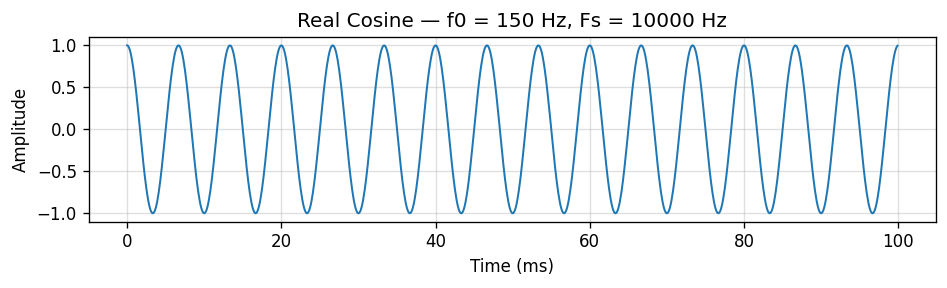

In [5]:
# plt.subplots() creates a figure and returns two objects: fig and ax.
# MATLAB equivalent: figure; ax = gca;
# figsize=(width, height) is a tuple — Python's immutable fixed-length sequence.
# Units are inches. MATLAB: set(gcf,'Units','inches','Position',[x y w h])
fig, ax = plt.subplots(figsize=(8, 2.5))

# t * 1e3 converts seconds to milliseconds — same arithmetic as MATLAB.
ax.plot(t * 1e3, x)

# ax.set() sets multiple axes properties in one call using keyword arguments.
# Avoids writing ax.set_xlabel(), ax.set_ylabel(), ax.set_title() separately.
# MATLAB equivalents: xlabel('...'), ylabel('...'), title('...')
ax.set(xlabel='Time (ms)', ylabel='Amplitude',
       title=f'Real Cosine — f0 = {f0} Hz, Fs = {Fs} Hz')

# Adjusts spacing so labels do not overlap — MATLAB has no direct equivalent.
plt.tight_layout()

# Renders and displays the figure.
plt.show()


## 2. Complex Baseband — The IQ Representation

In all modern wireless systems (LTE, 5G NR, Wi-Fi), signals are processed at **complex baseband** rather than as real bandpass waveforms.
The receiver down-converts the RF signal to produce two streams:

- **I (In-phase):** the real part
- **Q (Quadrature):** the imaginary part, 90° phase-shifted relative to I

A real bandpass cosine at carrier frequency $f_c$ has a complex baseband equivalent — a rotating **phasor**:

$$\tilde{x}[n] = e^{j 2\pi f_c n / F_s} = \underbrace{\cos(2\pi f_c n/F_s)}_{I} + j\underbrace{\sin(2\pi f_c n/F_s)}_{Q}$$

The imaginary unit in Python/NumPy is `1j` — **same syntax as MATLAB**.
In the IQ plane, this signal traces a perfect unit circle, rotating at $f_c$ revolutions per second.
The **envelope** $|\tilde{x}[n]| = 1$ is constant — there is no amplitude modulation here.

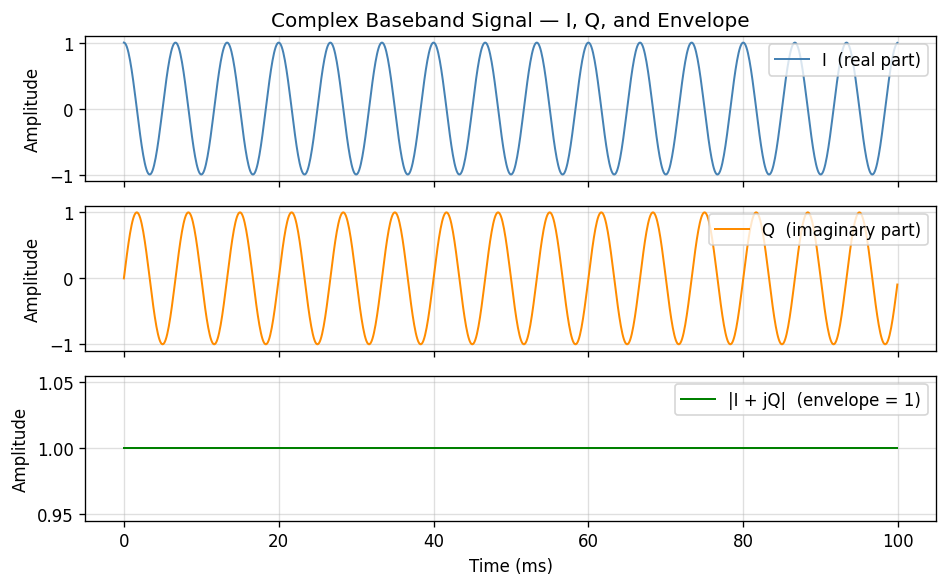

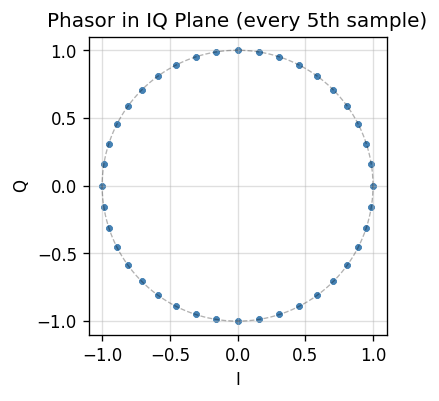

In [6]:
# 1j is Python's imaginary unit — same as 1j (or 1i) in MATLAB.
# ** is Python's power operator.
# MATLAB uses .^ for element-wise power on arrays.
# MATLAB equivalent: x_iq = exp(1j*2*pi*f0*t)
x_iq = np.exp(1j * 2 * np.pi * f0 * t)

# plt.subplots(3, 1) creates a 3-row, 1-column grid of subplots.
# sharex=True links all x-axes — zooming one panel zooms all.
# MATLAB equivalent: linkaxes(ax_array, 'x')
# 'axes' is a NumPy array: axes[0], axes[1], axes[2].
fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)

# .real and .imag extract real/imaginary parts — no parentheses needed.
# MATLAB equivalents: real(x_iq) and imag(x_iq)
axes[0].plot(t * 1e3, x_iq.real, color='steelblue',
             label='I  (real part)')
axes[1].plot(t * 1e3, x_iq.imag, color='darkorange',
             label='Q  (imaginary part)')
axes[2].plot(t * 1e3, np.abs(x_iq), color='green',
             label='|I + jQ|  (envelope = 1)')

# A for loop over a list or array.
# MATLAB equivalent: for i = 1:length(axes) ... end
for ax in axes:
    ax.legend(loc='upper right')
    ax.set_ylabel('Amplitude')
axes[2].set_xlabel('Time (ms)')
axes[0].set_title('Complex Baseband Signal — I, Q, and Envelope')
plt.tight_layout()
plt.show()

# subplot_kw passes settings to each Axes object at creation time.
# 'aspect': 'equal' ensures the IQ circle is not distorted.
# MATLAB equivalent: axis equal
fig, ax = plt.subplots(figsize=(3.5, 3.5), subplot_kw={'aspect': 'equal'})

# np.linspace: same as MATLAB linspace()
theta = np.linspace(0, 2*np.pi, 300)

# 'k--': shorthand format string — 'k' = black, '--' = dashed.
# Same convention as MATLAB: plot(x, y, 'k--')
# alpha: transparency (0 = invisible, 1 = fully opaque).
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)

# [::5] means 'every 5th element from start to end'.
# MATLAB equivalent: x_iq(1:5:end)
ax.scatter(x_iq.real[::5], x_iq.imag[::5], s=8,
           color='steelblue', alpha=0.7)
ax.set(xlabel='I', ylabel='Q',
       title='Phasor in IQ Plane (every 5th sample)')
plt.tight_layout()
plt.show()


## 3. Additive White Gaussian Noise (AWGN)

AWGN is the standard model for thermal receiver noise. The received signal is:

$$r[n] = x[n] + w[n], \qquad w[n] \sim \mathcal{N}(0,\, \sigma^2)$$

Noise samples are **i.i.d.** (independent, identically distributed) Gaussian with zero mean and variance $\sigma^2$.
"White" means the power spectral density is flat across all frequencies — every frequency bin sees the same noise power.

**Signal-to-Noise Ratio:**

$$\text{SNR}_{\text{dB}} = 10\log_{10}\!\left(\frac{P_{\text{signal}}}{\sigma^2}\right)$$

To generate noise at a **target SNR**, we measure the signal power, derive the required $\sigma^2$, and scale `randn` output accordingly:

- MATLAB: `noise = sqrt(sigma2) * randn(1, N);`
- Python: `noise = np.sqrt(sigma2) * np.random.randn(N)`

At SNR = 0 dB the noise power equals the signal power. Below 0 dB the noise dominates.

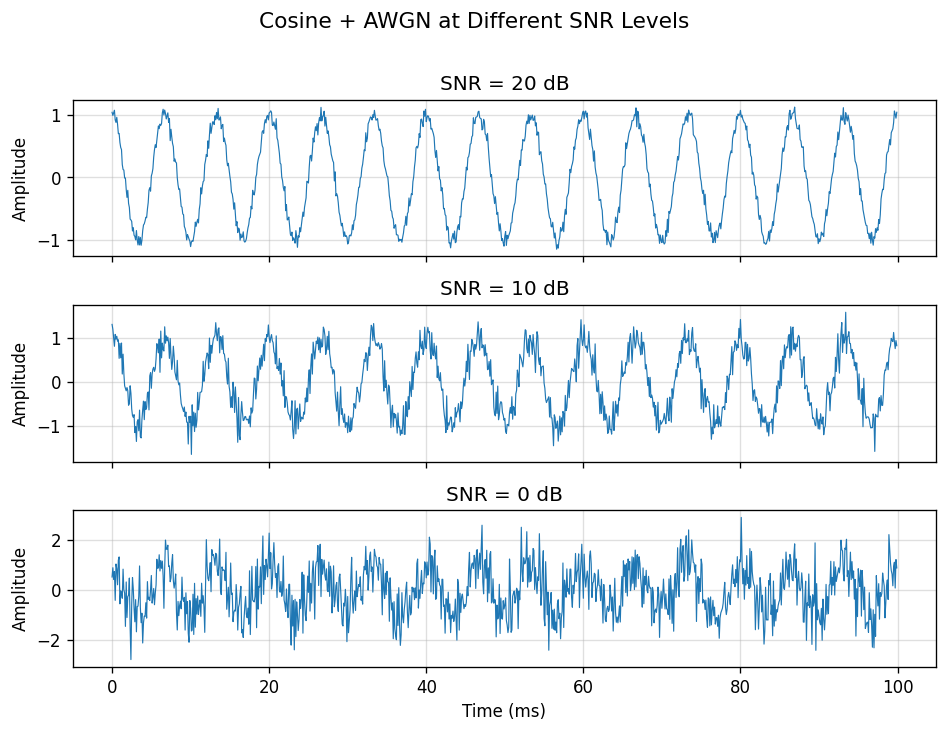

In [7]:
# 'def' defines a reusable function.
# MATLAB equivalent: function [out1, out2] = name(in1, in2)
#
# The triple-quoted string immediately after def is a docstring —
# Python's standard way to document functions. Access with: help(add_awgn)
# MATLAB equivalent: % comment lines above the function.
def add_awgn(signal, snr_db):
    """Add AWGN to a signal at a specified SNR (dB).
    Returns (noisy_signal, noise).
    """
    # ** is element-wise power — MATLAB: .^
    signal_power = np.mean(np.abs(signal) ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))

    # np.random.randn: same as MATLAB randn()
    noise = np.sqrt(noise_power) * np.random.randn(len(signal))

    # Python functions can return multiple values separated by a comma.
    # MATLAB equivalent: [noisy, noise] = add_awgn(signal, snr_db)
    return signal + noise, noise

# Fix the random seed so results are reproducible.
# MATLAB equivalent: rng(42)
np.random.seed(42)

# zip() pairs two sequences element by element for use in a for loop.
# Each 'ax' is paired with one SNR value from the list.
# MATLAB equivalent: for i = 1:3; ax = axes(i); snr = snr_list(i); ... end
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for ax, snr in zip(axes, [20, 10, 0]):
    x_noisy, _ = add_awgn(x, snr)
    # _ is a Python convention meaning 'I am ignoring this return value'.
    ax.plot(t * 1e3, x_noisy, linewidth=0.7)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'SNR = {snr} dB')

# Negative index [-1] means the last element.
# MATLAB equivalent: axes(end)
axes[-1].set_xlabel('Time (ms)')

# plt.suptitle adds a title above all subplots.
# MATLAB equivalent: sgtitle()
plt.suptitle('Cosine + AWGN at Different SNR Levels', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# Numerically verify that the generated noise hits the target SNR.

# String multiplication: '-' * 30 repeats the character 30 times.
# MATLAB equivalent: repmat('-', 1, 30)
header = '  Target SNR  |  Measured SNR'
print(header)
print('-' * len(header))

for snr_target in [20, 10, 0, -5]:
    _, noise = add_awgn(x, snr_target)
    measured = 10 * np.log10(np.mean(x**2) / np.mean(noise**2))
    # f-string format: {value:>9.2f}
    # > = right-align, 9 = field width, .2f = 2 decimal places.
    # MATLAB equivalent: fprintf('%9.2f\n', measured)
    print(f'  {snr_target:>8} dB  |  {measured:>9.2f} dB')


  Target SNR  |  Measured SNR
-----------------------------
        20 dB  |      19.77 dB
        10 dB  |      10.06 dB
         0 dB  |      -0.07 dB
        -5 dB  |      -5.21 dB


## 4. Frequency Domain — FFT and Power Spectrum

The Fast Fourier Transform (FFT) decomposes the signal into its sinusoidal frequency components.
NumPy's `fft` is identical in behaviour to MATLAB's `fft`.

**Key steps — same as MATLAB:**
1. `np.fft.fft(x)` — compute the DFT (output is complex, length $N$)
2. `np.fft.fftshift(...)` — shift the zero-frequency bin to the centre (≡ MATLAB `fftshift`)
3. `np.fft.fftfreq(N, 1/Fs)` — construct the frequency axis in Hz

A real cosine at $f_0$ appears as **two impulses at $\pm f_0$** in the two-sided spectrum — one for each complex exponential in Euler's formula.
When AWGN is added, a **flat noise floor** appears across all bins; its height is determined by $\sigma^2 / N$.

**Amplitude in dBFS** (dB relative to full scale): $\; 20\log_{10}|X[k]/N|$

Normalising by $N$ ensures that the peak amplitude of a unit-amplitude cosine reads 0 dBFS, matching the `fft(x)/N` MATLAB convention.

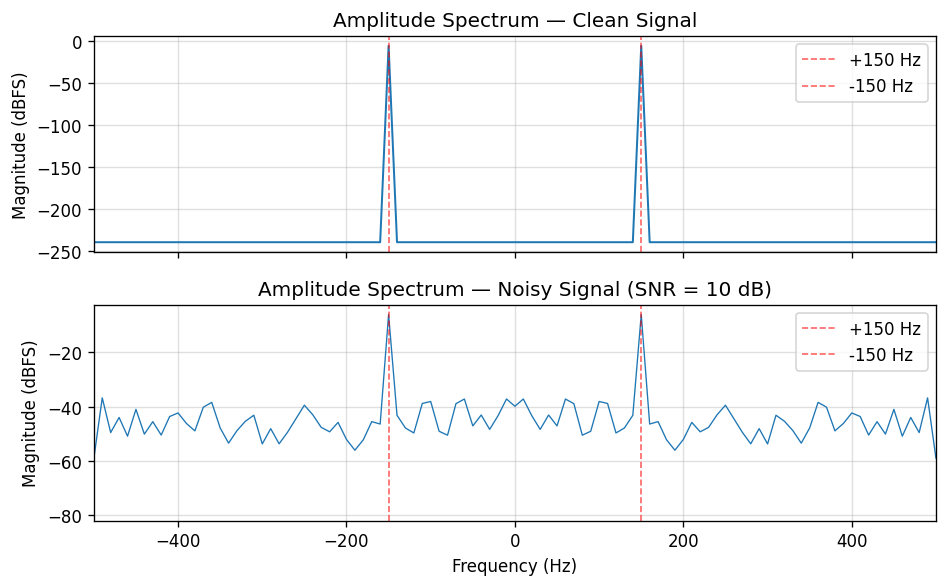

In [9]:
def compute_spectrum(sig, Fs):
    """Two-sided amplitude spectrum in dBFS, normalised by N."""
    N = len(sig)

    # np.fft.fft(): identical to MATLAB's fft()
    # np.fft.fftshift(): moves 0 Hz to the centre.
    # Identical to MATLAB's fftshift()
    # Dividing by N normalises amplitude — same as fft(x)/N in MATLAB.
    X = np.fft.fftshift(np.fft.fft(sig)) / N

    # np.fft.fftfreq returns frequency bin centres in Hz.
    # MATLAB equivalent: f = (-N/2 : N/2-1) * Fs/N
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))

    # np.abs() computes magnitude of complex numbers — MATLAB: abs()
    # Adding 1e-12 prevents log(0) = -inf for zero-energy bins.
    mag = 20 * np.log10(np.abs(X) + 1e-12)
    return freqs, mag

np.random.seed(0)
x_noisy_10dB, _ = add_awgn(x, 10)

freqs, mag_clean = compute_spectrum(x, Fs)
_, mag_noisy     = compute_spectrum(x_noisy_10dB, Fs)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(freqs, mag_clean)
axes[0].set(title='Amplitude Spectrum — Clean Signal',
             ylabel='Magnitude (dBFS)')

axes[1].plot(freqs, mag_noisy, linewidth=0.8)
axes[1].set(title='Amplitude Spectrum — Noisy Signal (SNR = 10 dB)',
             ylabel='Magnitude (dBFS)', xlabel='Frequency (Hz)')

for ax in axes:
    # set_xlim: equivalent to MATLAB's xlim([-500 500])
    ax.set_xlim([-500, 500])
    # axvline draws a vertical reference line — MATLAB: xline()
    ax.axvline( f0, color='red', linestyle='--',
               alpha=0.6, linewidth=1, label=f'+{f0} Hz')
    ax.axvline(-f0, color='red', linestyle='--',
               alpha=0.6, linewidth=1, label=f'-{f0} Hz')
    ax.legend()
plt.tight_layout()
plt.show()


## 5. Spectrogram — Time-Frequency Analysis

### Why the FFT alone is not enough

The FFT gives a **single, time-averaged snapshot** of frequency content — it cannot reveal *when* a frequency appeared or how the spectrum evolves over time.
Many real-world signals have time-varying spectral structure:

- A radar chirp sweeping from low to high frequency
- A 5G NR slot where DMRS pilots occupy specific OFDM symbols
- A frequency-hopped (FHSS) signal

The FFT collapses all of this time structure into one averaged picture, making the sweep invisible.

### Short-Time Fourier Transform (STFT)

The STFT solves this by sliding a short analysis window $w[\tau]$ along the signal and computing the FFT at each position $m$:

$$X[m, k] = \sum_{\tau=0}^{L-1} x[mH + \tau]\, w[\tau]\, e^{-j2\pi k\tau / N_{\text{FFT}}}$$

where $L$ is the **window length**, $H$ is the **hop size** (stride between windows), and $k$ is the frequency bin index.
The result is a 2-D array indexed by time frame $m$ and frequency bin $k$.

The **spectrogram** is the squared magnitude:

$$S[m, k] = |X[m, k]|^2$$

### Time-frequency trade-off

There is a fundamental uncertainty principle (analogous to Heisenberg in quantum mechanics) that limits simultaneous time and frequency resolution:

$$\Delta t \cdot \Delta f \geq \frac{1}{4\pi}$$

| Window length | Time resolution | Frequency resolution |
|:---:|:---:|:---:|
| Short (e.g. 64 samples) | Fine — captures rapid changes | Poor — wide frequency bins |
| Long (e.g. 1024 samples) | Poor — temporal blurring | Fine — narrow frequency bins |

This is the same trade-off behind the 5G NR **subcarrier spacing (SCS)** choice:
15 kHz SCS uses a long OFDM symbol (≈ 66.7 µs, fine frequency resolution),
while 120 kHz SCS uses a short symbol (≈ 8.3 µs, better time resolution for high-mobility channels).

### Chirp signal for demonstration

A static tone produces a flat horizontal line in the spectrogram — it teaches
nothing about time-frequency structure.
Instead we use a **linear chirp**: a sine wave whose instantaneous frequency
increases linearly with time.

At $t = 0$ the frequency is $f_0$, and at $t = t_1$ it is $f_1$.
At any time in between, the instantaneous frequency is:

$$f(t) = f_0 + \frac{f_1 - f_0}{t_1} \cdot t$$

The rate of change is constant:

$$\frac{df}{dt} = \frac{f_1 - f_0}{t_1} \quad \text{(Hz per second)}$$

**In our example** ($f_0 = 50$ Hz, $f_1 = 2000$ Hz, $t_1 = 1$ s):

$$\frac{df}{dt} = \frac{2000 - 50}{1.0} = 1950 \text{ Hz/s}$$

So at $t = 0.5$ s the instantaneous frequency is:

$$f(0.5) = 50 + 1950 \times 0.5 = 1025 \text{ Hz}$$

This is exactly why the spectrogram shows a **straight diagonal line** —
the frequency increases at a constant rate, so frequency vs. time is linear.
If you used `method='quadratic'`, the line would curve.


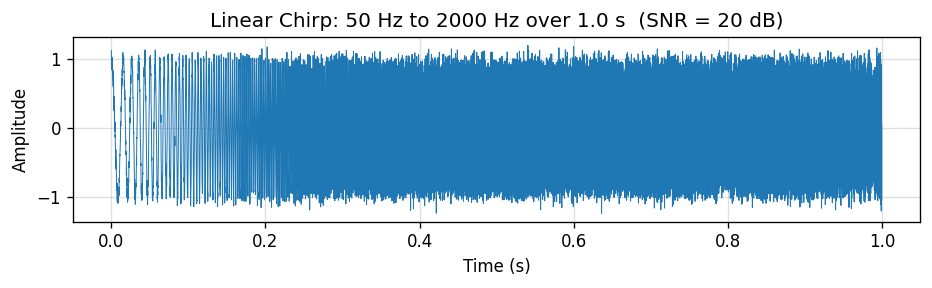

In [10]:
Fs_ch = 8_000
T_ch  = 1.0

# np.linspace(start, stop, num) — same as MATLAB linspace()
# endpoint=False excludes the stop value to avoid a duplicate sample.
# int() converts float to integer — array sizes must be integers.
t_ch = np.linspace(0, T_ch, int(Fs_ch * T_ch), endpoint=False)

# Assign multiple variables in one line using tuple unpacking.
# MATLAB equivalent: f_start = 50; f_end = 2000;
f_start, f_end = 50, 2000

# scipy.signal.chirp() — full signature:
#   chirp(t, f0, t1, f1, method=)
#
#   t      : time vector (required, always first, no keyword label)
#   f0     : instantaneous frequency at t = 0 (Hz)
#   t1     : reference end time (s) — frequency f1 is reached at this time
#   f1     : instantaneous frequency at t = t1 (Hz)
#   method : shape of the sweep —
#            'linear'      frequency changes at a constant rate
#            'quadratic'   frequency changes quadratically (curved sweep)
#            'logarithmic' frequency changes on a log scale
#
# Keyword arguments (f0=, t1=, f1=, method=) can be in any order.
# t_ch has no keyword label — it is positional and always comes first.
# MATLAB equivalent: chirp(t_ch, f_start, T_ch, f_end)
x_chirp = chirp(t_ch, f0=f_start, f1=f_end, t1=T_ch, method='linear')

np.random.seed(7)
x_chirp_noisy, _ = add_awgn(x_chirp, 20)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_ch, x_chirp_noisy, linewidth=0.6)
ax.set(xlabel='Time (s)', ylabel='Amplitude',
       title=f'Linear Chirp: {f_start} Hz to {f_end} Hz  (SNR = 20 dB)')
plt.tight_layout()
plt.show()


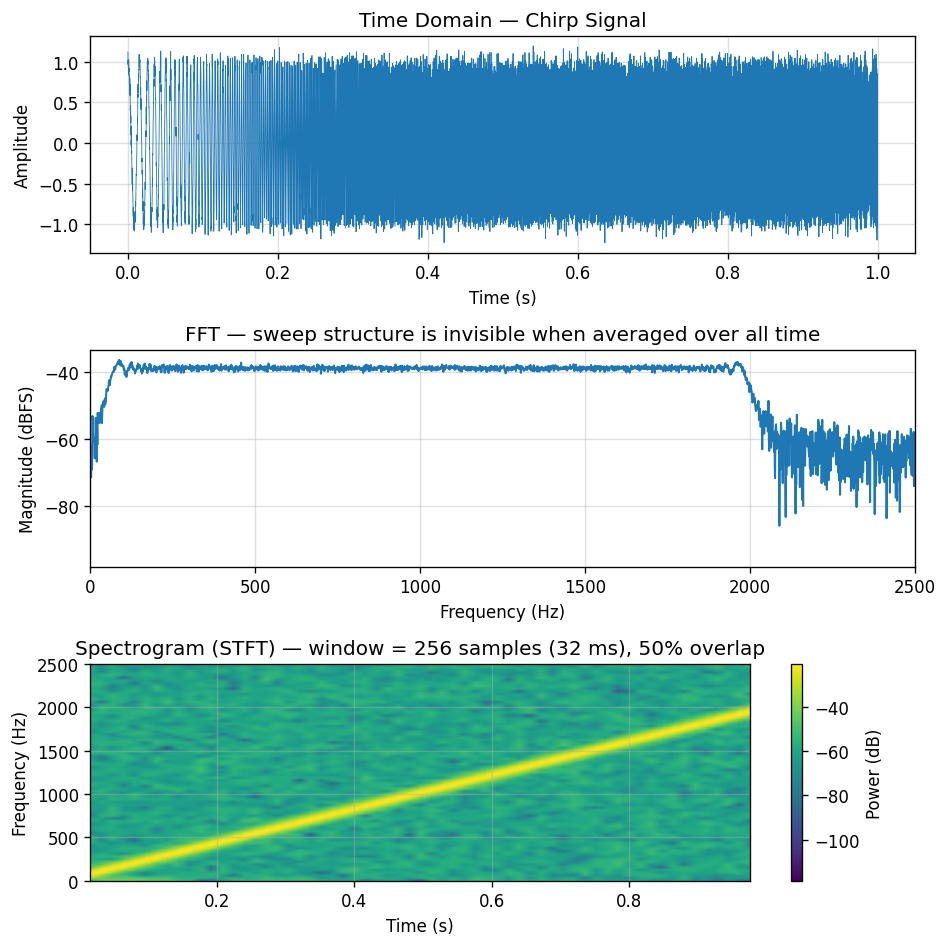

In [11]:
# Side-by-side: FFT (time-averaged) vs spectrogram (time-resolved)

# Window length in samples: 256 / 8000 Hz = 32 ms per frame.
nperseg = 256

# // is integer (floor) division — MATLAB: floor(nperseg / 2)
noverlap = nperseg // 2

# spectrogram() returns three arrays as a tuple:
# (frequencies, times, power_matrix)
# Tuple unpacking assigns all three in one line.
# MATLAB equivalent: [s, f, t] = spectrogram(...)
f_sg, t_sg, Sxx = spectrogram(x_chirp_noisy, fs=Fs_ch,
                               nperseg=nperseg,
                               noverlap=noverlap,
                               window='hann')

freqs_ch, mag_ch = compute_spectrum(x_chirp_noisy, Fs_ch)

fig, axes = plt.subplots(3, 1, figsize=(8, 8))

axes[0].plot(t_ch, x_chirp_noisy, linewidth=0.5)
axes[0].set(xlabel='Time (s)', ylabel='Amplitude',
             title='Time Domain — Chirp Signal')

# --- Boolean masking ---
# freqs_ch >= 0 does not return a single True/False.
# It returns an array of True/False, one value per element:
#
#   freqs_ch = [-2000, -1000, 0, 1000, 2000]
#   freqs_ch >= 0 -> [False, False, True, True, True]
#
# Using this as an index keeps only elements where value is True:
#   freqs_ch[pos_mask] -> [0, 1000, 2000]
#
# Here we use it to plot only the positive frequency side (0 to
# 2500 Hz), since compute_spectrum returns both +/- frequencies.
# MATLAB equivalent: freqs_ch(freqs_ch >= 0)
pos_mask = freqs_ch >= 0
axes[1].plot(freqs_ch[pos_mask], mag_ch[pos_mask])
axes[1].set(xlabel='Frequency (Hz)', ylabel='Magnitude (dBFS)',
             title='FFT — sweep hidden when averaged over all time',
             xlim=[0, 2500])

# --- pcolormesh ---
# Displays a 2D matrix as a heatmap — each cell is coloured
# based on its value. Think of it as a coloured grid where:
#   t_sg  -> x-axis: time position of each STFT frame
#   f_sg  -> y-axis: frequency bins
#   Sxx   -> the power value at each (time, frequency) point,
#            converted to dB — this determines the colour
#
# shading='gouraud': smoothly interpolates colours between grid
#   points (like bilinear interpolation). Without it you get a
#   blocky, pixelated look.
#
# cmap='viridis': the colour scale used to map power to colour.
#   dark purple = low power, yellow = high power.
#
# MATLAB equivalent: imagesc() or pcolor()
im = axes[2].pcolormesh(t_sg, f_sg, 10 * np.log10(Sxx + 1e-12),
                         shading='gouraud', cmap='viridis')
win_ms = nperseg / Fs_ch * 1e3
axes[2].set(
    xlabel='Time (s)', ylabel='Frequency (Hz)',
    title=(
        f'Spectrogram (STFT) — window = {nperseg} samples'
        f' ({win_ms:.0f} ms)'
    ),
    ylim=[0, 2500]
)

# colorbar adds a colour scale on the side — MATLAB: colorbar
fig.colorbar(im, ax=axes[2], label='Power (dB)')
plt.tight_layout()
plt.show()


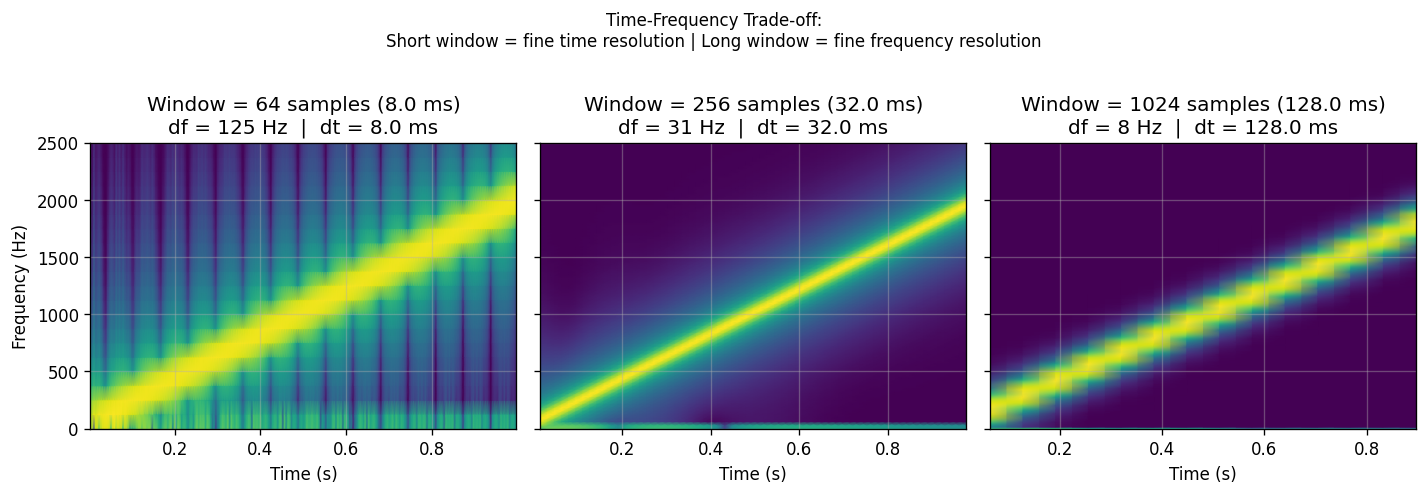

In [12]:
# Visualise the time-frequency trade-off by varying window length.

# plt.subplots(1, 3) creates 1 row, 3 columns of subplots.
# sharey=True links all y-axes — MATLAB: linkaxes(ax_array, 'y')
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# zip(axes, [...]) pairs each subplot with one window size.
# MATLAB equivalent: for i = 1:3; nper = win_sizes(i); ... end
for ax, nper in zip(axes, [64, 256, 1024]):
    f_s, t_s, S = spectrogram(x_chirp, fs=Fs_ch,
                               nperseg=nper,
                               noverlap=nper // 2,
                               window='hann')
    ax.pcolormesh(t_s, f_s, 10 * np.log10(S + 1e-12),
                  shading='gouraud', cmap='viridis')
    freq_res    = Fs_ch / nper
    time_res_ms = nper / Fs_ch * 1e3
    ax.set(
        title=(
            f'Window = {nper} samples ({time_res_ms:.1f} ms)\n'
            f'df = {freq_res:.0f} Hz  |  dt = {time_res_ms:.1f} ms'
        ),
        xlabel='Time (s)',
        ylim=[0, 2500]
    )

axes[0].set_ylabel('Frequency (Hz)')
plt.suptitle(
    'Time-Frequency Trade-off:\n'
    'Short window = fine time res. | Long window = fine freq. res.',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()


## MATLAB to Python / NumPy Quick Reference

| Operation | MATLAB | Python (NumPy / SciPy) |
|-----------|--------|------------------------|
| Time vector | `t = 0:1/Fs:T-1/Fs;` | `t = np.arange(0, T, 1/Fs)` |
| Cosine | `cos(2*pi*f0*t)` | `np.cos(2*np.pi*f0*t)` |
| Complex exponential | `exp(1j*2*pi*f0*t)` | `np.exp(1j*2*np.pi*f0*t)` |
| Real / imaginary part | `real(x)` / `imag(x)` | `x.real` / `x.imag` |
| Envelope | `abs(x)` | `np.abs(x)` |
| White Gaussian noise | `randn(1, N)` | `np.random.randn(N)` |
| Signal power | `mean(abs(x).^2)` | `np.mean(np.abs(x)**2)` |
| FFT | `fft(x)` | `np.fft.fft(x)` |
| Centred FFT | `fftshift(fft(x))` | `np.fft.fftshift(np.fft.fft(x))` |
| Frequency axis (Hz) | `(-N/2:N/2-1)*Fs/N` | `np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))` |
| dB magnitude | `20*log10(abs(X))` | `20*np.log10(np.abs(X))` |
| Linear chirp | `chirp(t, f0, T, f1)` | `scipy.signal.chirp(t, f0, f1, t1)` |
| Spectrogram | `spectrogram(x, win, nov, nfft, Fs)` | `scipy.signal.spectrogram(x, fs=Fs, nperseg=L, noverlap=H)` |